# Idea 2 - Evidence selection → extraction → constrained answering
1. Prompt VLM to list specific flowchart elements (conditions / decisions / outcomes) that are required to answer the question.
1. Prompt VLM to detect whether each listed element is present in the flowchart and extracts its values.
1. Prompt VLM to answer the question using only verified elements.

# Experiment
1. Try with a few samples
2. Evaluate dev score

In [4]:
flowvqa_dev_df

,question_id,question,answer,type
wiki00071,1,What book should be read for a humorous take o...,'Zhuangzi Speaks' and 'The Tao Speaks',fact_retrieval
wiki00071,2,What should one seek when searching for transl...,Quality and accuracy,fact_retrieval
wiki00071,3,Assuming I'm at the step where I'm comparing t...,The immediate next steps would be 'Use the sel...,flow_referential
wiki00071,4,How many nodes exist in the given flowchart?,25,topological
wiki00071,5,How many edges exist in the given flowchart?,29,topological
...,...,...,...,...
instruct00811,6,Assuming I am currently at the step where I am...,"If difficulty is encountered, the next step wo...",flow_referential
instruct00811,7,How many nodes exist in the given flowchart?,22,topological
instruct00811,8,How many edges exist in the given flowchart?,25,topological
instruct00811,9,How many edges exist in the shortest path betw...,2,topological


In [14]:
# Helper functions
import base64
import os
import random
from typing import List
from PIL import Image
from openai import OpenAI
import pandas as pd
import json
from IPython.display import display, HTML


VLM_MODEL_ID = "openai/gpt-5.1-chat"
LLM_MODEL_ID = "openai/gpt-5.1-chat"
openai_client = OpenAI(base_url="https://openrouter.ai/api/v1", api_key=os.environ["OPENROUTER_API_KEY"])

# Load FlowVQA dev set JSON
with open("../data/flowvqa/dev.json", "r") as f:
    flowvqa_dev_set = json.load(f)

# Form a Pandas DataFrame
records = []
index = []
for k, v in flowvqa_dev_set.items():                
    for question_id, qa in v["qa"].items():
        records.append({
            "question_id": question_id,
            "question": qa["Q"],
            "answer": qa["A1"],
            "type": qa["type"]
        })
        index.append(k)
flowvqa_dev_df = pd.DataFrame(records, index=index)


'''
Sample 5 flowcharts from FlowVQA dev set for smoke test, with the constraint that:
    - 1 code flowchart
    - 1 wiki flowchart
    - 1 instruct flowchart
    - 2 randomly sampled flowcharts
Inputs:
    - boolean indicating whether to display the sampled flowcharts
    - random seed
    - maximum width or height for display (pixels)
Outputs:
    - list of sampled flowchart names
'''
def sample_5_flowcharts(
    display_flowchart: bool = False,
    seed: int | None = None
) -> List[str]:
    if seed is not None:
        random.seed(seed)  

    flowchart_names = list(flowvqa_dev_set.keys())

    code_flowchart = None
    instruct_flowchart = None
    wiki_flowchart = None
    for x in flowchart_names:
        if (not code_flowchart) and x.startswith("code"):
            code_flowchart = x
        elif (not instruct_flowchart) and x.startswith("instruct"):
            instruct_flowchart = x
        elif (not wiki_flowchart) and x.startswith("wiki"):
            wiki_flowchart = x
        if code_flowchart and instruct_flowchart and wiki_flowchart:
            break

    flowchart_names.remove(code_flowchart)
    flowchart_names.remove(instruct_flowchart)
    flowchart_names.remove(wiki_flowchart)
    random_samples = random.sample(flowchart_names, 2)
    sampled_flowcharts = [code_flowchart, instruct_flowchart, wiki_flowchart] + random_samples

    if display_flowchart:
        for p in sampled_flowcharts:
            # clear visual separation
            display(HTML("<hr style='margin:16px 0'>"))
            
            # show filename / context
            display(HTML(f"<div style='font-family:monospace;opacity:0.7'>{p}</div>"))
            
            # load and shrink image to avoid huge output
            img = Image.open(os.path.join("/app/data/flowvqa/images/", p + ".png"))
            img.thumbnail((400, 400))
            display(img)
            print("\n\n".join(flowvqa_dev_df.loc[p]["question"].tolist()))
            
    return sampled_flowcharts


'''
Query the VLM with image and a text prompt.
Inputs:
    - image file path
    - text prompt
Outputs:
    - response by the VLM
'''
def query_VLM(image_path, prompt, max_new_tokens=4096, temperature=0.0):
    # encode as base64 binary
    with open(image_path, "rb") as image_file:
        image =  base64.b64encode(image_file.read()).decode("utf-8")

    messages = [
                {"role": "system", "content": "You are a helpful assistant."},
                {
                    "role": "user",
                    "content": [
                        {"type": "text", "text": prompt},
                        {
                            "type": "image_url",
                            "image_url": {
                                "url": f"data:image/jpeg;base64,{image}",
                                "detail": "high",
                            },
                        },
                    ],
                },
            ]

    completion = openai_client.chat.completions.create(
        model=VLM_MODEL_ID,
        max_tokens=max_new_tokens,
        temperature=temperature,
        messages=messages,
        extra_body={"provider": {"only": ["openai"]}},
    )
    
    response = completion.choices[0].message.content
    return response


'''
Query the LLM with a text prompt.
Inputs:
    - text prompt
Outputs:
    - response by the LLM
'''
def query_LLM(prompt, max_new_tokens=4096, temperature=0.0):
    messages = [
                {"role": "system", "content": "You are a helpful assistant."},
                {"role": "user", "content": prompt},
            ]

    completion = openai_client.chat.completions.create(
        model=LLM_MODEL_ID,
        max_tokens=max_new_tokens,
        temperature=temperature,
        messages=messages,
        extra_body={"provider": {"only": ["openai"]}},
    )
    
    response = completion.choices[0].message.content
    return response

# Sample 5 flowcharts for smoke test

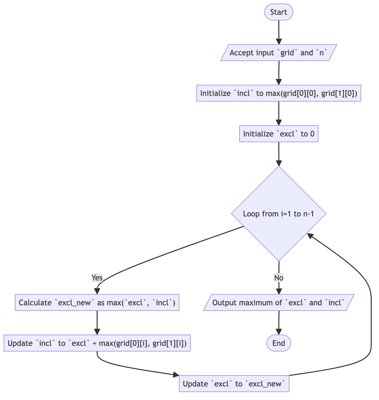

How is the initial value of 'incl' determined?

Imagine you are writing a program to process a grid of numbers for a game. You've just initialized two variables, `incl` and `excl`, and you're about to enter a loop that starts with `i=1`. In this loop, you need to update a variable `excl_new`. Based on the algorithm you're following, what value should `excl_new` be assigned?

As you continue to iterate through the grid in your number-crunching application, you find yourself updating two variables, `incl` and `excl`, at each step. Once you have calculated the new value for `incl`, which involves adding the maximum of grid[0][i] or grid[1][i] to `excl`, what's the next immediate action you must take before the next iteration?

What will be the value of `incl` after the first iteration of the loop starting at node E, given that `grid` is a 2x2 matrix with values [[1,2],[3,4]]?

If the loop at node E has completed two iterations for an input `n` of 3, what will be the sequence of steps exec

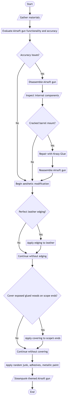

What should be done if there are accuracy issues with the Airsoft gun?

How should a cracked barrel mount on the Airsoft gun be repaired?

Liam is customizing an Airsoft gun to fit a Steampunk theme for his short film, but he's having trouble giving the leather pieces a finished look with perfect edging. If he can't figure out how to edge the leather properly, what should he do to keep the project moving forward?

Assuming the Airsoft gun has been disassembled due to accuracy issues, what would be the next step if the internal components inspection reveals no cracked barrel mount?

How many nodes exist in the given flowchart?

How many edges exist in the given flowchart?

Is the node ""Steampunk-themed Airsoft gun"" direct predecessor of the node ""Apply edging to leather""?

How many edges exist in the shortest path between ""Cracked barrel mount?"" and ""Steampunk-themed Airsoft gun""?

An indegree of is the number of incoming edges for a node in a flowchart. What is the maximum inde

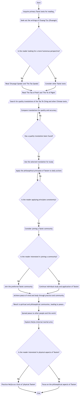

What book should be read for a humorous take on Taoist philosophy?

What should one seek when searching for translations of the Tao Te Ching?

Assuming I'm at the step where I'm comparing translations for quality and accuracy, and I eventually find a quality translation, what are the immediate next two steps in the process?

How many nodes exist in the given flowchart?

How many edges exist in the given flowchart?

Is the node ""Read 'The Tao of Pooh' and 'The Te of Piglet'"" direct predecessor of the node ""Focus on the philosophical aspects of Taoism""?


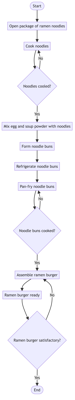

After mixing the egg and soup powder with noodles, what is the next step?

Leo is preparing to make ramen burgers for his food blog and wants to capture every detail of the process. After boiling the noodles, what critical step should he document next to ensure the noodles are ready for the subsequent stages?

If I'm currently at the step where I need to refrigerate noodle buns, what was the immediate previous step and what is the next step?

How many nodes exist in the given flowchart?

How many edges exist in the given flowchart?

Is the node ""Ramen burger satisfactory?"" direct successor of the node ""Refrigerate noodle buns""?

How many edges exist in the shortest path between ""Assemble ramen burger"" and ""End""?

Is the node ""Ramen burger satisfactory?"" direct successor of the node ""Ramen burger ready""?


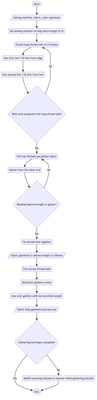

What stitch length should be set on the sewing machine for gathering fabric?

How far from the edge should the first line of stitching be when gathering fabric?

What is the final step to secure the gathers in the fabric?

Liam has gathered his fabric to the correct fullness and has secured the gathers by tying the thread tails. However, he's unsure if he should cut off the excess thread right away. What is the next step he should take according to the instructions?

If I am currently at the step where I am pulling the top threads to gather the fabric, but find that the gathers are not to the desired length, what will my next two steps be?

Assuming I have just finished sewing over the gathers with a normal stitch length, but the gathering technique is not yet complete, what is my immediate next action?

How many nodes exist in the given flowchart?

How many edges exist in the given flowchart?

How many edges exist in the shortest path between ""Tie thread tails together"" and ""Fabric

['code00268', 'instruct00856', 'wiki00071', 'instruct00665', 'instruct00286']

In [15]:
sample_5_flowcharts(True, 888)

# Implement idea

In [26]:
import json, re


def list_relevant_flowchart_elements(question):
    prompt_template = """# Task
Given a question whose answer must be derived from a flowchart image, identify the specific flowchart elements or structural properties that are strictly necessary to determine the answer.

Do NOT answer the question.
Do NOT infer whether the elements actually exist.
Only list what must be checked in the flowchart to answer the question.

Question: {question}

# Valid element types
You may output up to 5 items. Each item must be one of the following:

- a flowchart node corresponding to a specific concept mentioned or implied in the question
- upstream (ancestor) nodes of a specified node
- downstream (descendant) nodes of a specified node
- the total number of nodes
- the total number of edges
- a structural relationship between nodes (e.g., which node precedes another, whether two nodes are connected)

Do not include explanations or reasoning.
Output only a bullet list.

# Few-shot examples

## Example 1
Question: How many nodes are there?
Output:
- the total number of nodes

## Example 2
Question: How many edges exist in the flowchart?
Output:
- the total number of edges

## Example 3
Question: What should be done before writing code?
Output:
- the node corresponding to the action of writing code
- upstream nodes of the node corresponding to the action of writing code

# Output
"""
    return query_LLM(
        prompt_template.format(question=question)
    )

def detect_flowchart_elements(flowchart_elements, flowchart_image):
    prompt_template = """# Task
Given a list of flowchart elements or properties and an image containing a flowchart, detect whether each flowchart element can be found explicitly or derived from the flowchart in the image, then extract the values of all the detections.

Do NOT imagine existence of flowchart element.
Only detect that a flowchart element exists if it can be found explicitly or derived without ambiguity.

List of flowchart elements or properties: {flowchart_elements}

# Output format
- Do not include explanations or reasoning.
- Output only a Markdown table with 2 columns "Flowchart element or property", "Extracted value" and number of rows equal to the number of flowchart elements in the list.
- The "Flowchart element or property" column cells should contain the given list of flowchart elements or properties as-is without modification.
- The "Extracted value" column cells should either contain the extracted value or NOT_FOUND if the flowchart element or property is not detecte

# Few-shot examples

## Example 1
List of flowchart elements or properties:
- total number of nodes
Output:
| Flowchart element or property | Extracted value |
|-------------------------------|-----------------|
| number of nodes | 5 |

## Example 2
List of flowchart elements or properties:
- total number of edges
Output:
| Flowchart element or property | Extracted value |
|-------------------------------|-----------------|
| number of edges | 20 |

## Example 3
List of flowchart elements or properties:
- the node corresponding to the action of writing code
- upstream nodes of the node corresponding to the action of writing code
Output:
| Flowchart element or property | Extracted value |
|-------------------------------|-----------------|
| the node corresponding to the action of writing code | "you are now ready to start programming" |
| upstream nodes of the node corresponding to the action of writing code | 3 nodes "gather requirements", "plan software design", "design test cases" |

## Example 4
List of flowchart elements or properties:
- a node corresponding to the action of writing code progressing to a node corresponding to the action of running unit tests
Output:
| Flowchart element or property | Extracted value |
|-------------------------------|-----------------|
| a node corresponding to the action of writing code progressing to a node corresponding to the action of running unit tests | NOT_FOUND |

# Output
"""
    return query_VLM(
        prompt_template.format(flowchart_elements=flowchart_elements),
        flowchart_image
    )

In [ ]:
prompt_template = """# Task
    Given a list of flowchart elements or properties and an image containing a flowchart, detect whether each flowchart element can be found explicitly or derived from the flowchart in the image, then extract the values of all the detections.

Do NOT imagine existence of flowchart element.
Only detect that a flowchart element exists if it can be found explicitly or derived without ambiguity.

List of flowchart elements or properties: {flowchart_elements}

# Output format
- Do not include explanations or reasoning.
- Output only a Markdown table with 2 columns "Flowchart element or property", "Extracted value" and number of rows equal to the number of flowchart elements in the list.
- The "Flowchart element or property" column cells should contain the given list of flowchart elements or properties as-is without modification.
- The "Extracted value" column cells should either contain the extracted value or NOT_FOUND if the flowchart element or property is not detecte

# Few-shot examples

## Example 1
List of flowchart elements or properties:
- total number of nodes
Output:
| Flowchart element or property | Extracted value |
|-------------------------------|-----------------|
| number of nodes | 5 |

## Example 2
List of flowchart elements or properties:
- total number of edges
Output:
| Flowchart element or property | Extracted value |
|-------------------------------|-----------------|
| number of edges | 20 |

## Example 3
List of flowchart elements or properties:
- the node corresponding to the action of writing code
- upstream nodes of the node corresponding to the action of writing code
Output:
| Flowchart element or property | Extracted value |
|-------------------------------|-----------------|
| the node corresponding to the action of writing code | "you are now ready to start programming" |
| upstream nodes of the node corresponding to the action of writing code | 3 nodes "gather requirements", "plan software design", "design test cases" |

## Example 4
List of flowchart elements or properties:
- a node corresponding to the action of writing code progressing to a node corresponding to the action of running unit tests
Output:
| Flowchart element or property | Extracted value |
|-------------------------------|-----------------|
| a node corresponding to the action of writing code progressing to a node corresponding to the action of running unit tests | NOT_FOUND |

# Output
"""

# Dev score

# Analysis